# Модели без SMOTE

## Разделение данных

In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['figure.dpi'] = 300

In [80]:
df = pd.read_csv("../../card_transdata.csv")

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("fraud", axis=1)
y = df["fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Train class distribution:
fraud
0.0    0.91255
1.0    0.08745
Name: proportion, dtype: float64

Test class distribution:
fraud
0.0    0.912785
1.0    0.087215
Name: proportion, dtype: float64

Shapes:
X_train: (800000, 7)
X_test: (200000, 7)
X_train_scaled: (800000, 7)
X_test_scaled: (200000, 7)


На этапе подготовки данных исходная выборка была разделена на матрицу признаков и целевую переменную fraud. Далее данные были разделены на обучающую и тестовую выборки в соотношении 80/20 с использованием стратификации по целевому признаку. Это позволило сохранить исходное соотношение классов в обеих выборках, что особенно важно при наличии дисбаланса классов. После разделения было выполнено масштабирование признаков с помощью StandardScaler. Масштабирование применялось только после разделения данных, при этом параметры стандартизации рассчитывались исключительно на обучающей выборке, что позволило избежать утечки данных.

## Baseline модель

In [82]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

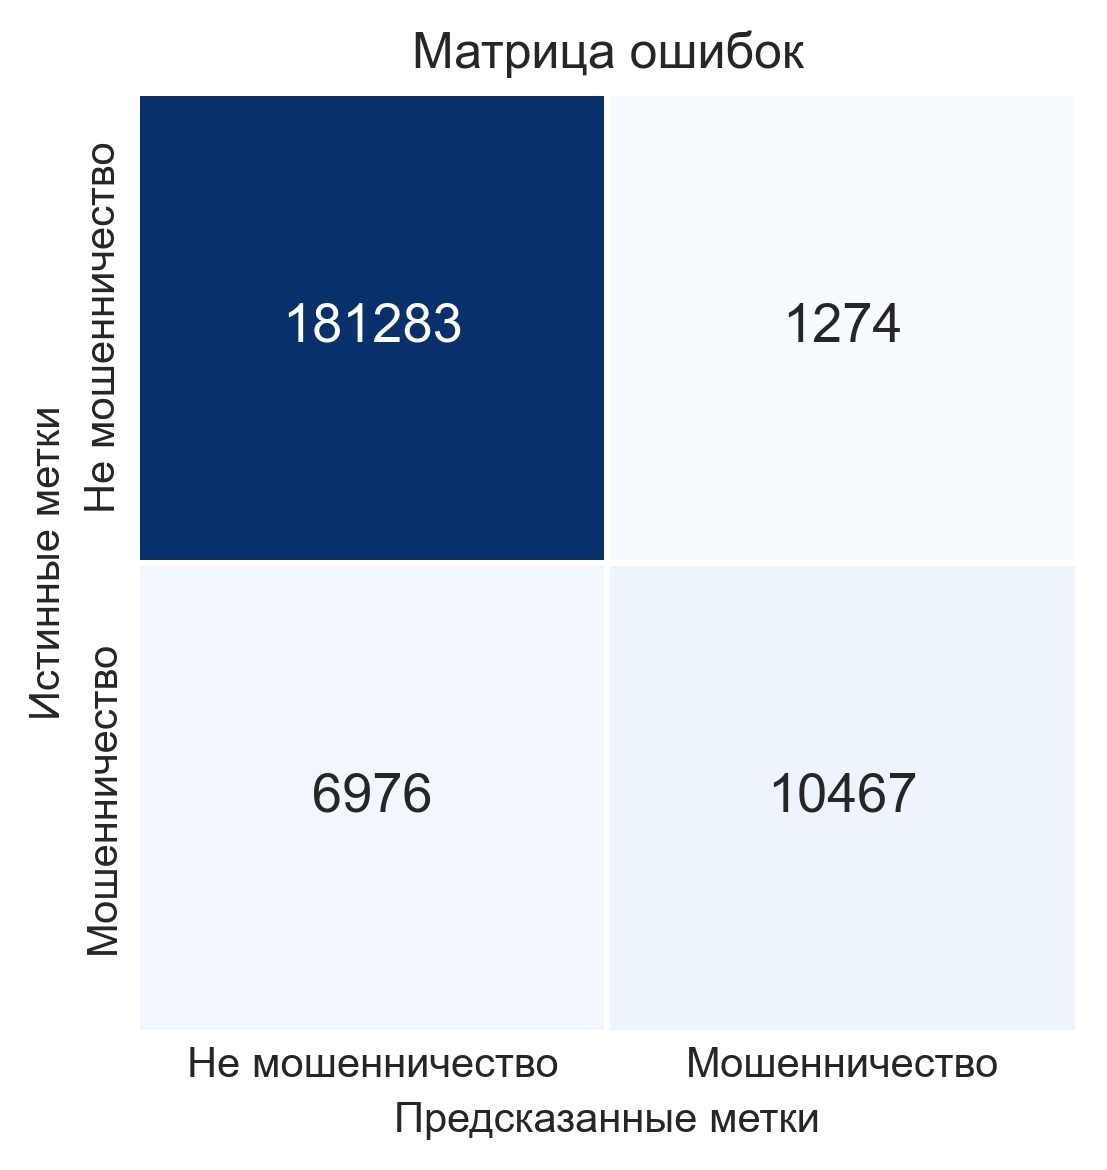

In [83]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
)

cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(4, 4), dpi=300)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=1,
    linecolor="white",
    xticklabels=["Не мошенничество", "Мошенничество"],
    yticklabels=["Не мошенничество", "Мошенничество"],
    annot_kws={"size": 13}
)

plt.xlabel("Предсказанные метки")
plt.ylabel("Истинные метки")
plt.title("Матрица ошибок")
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98    182557
         1.0       0.89      0.60      0.72     17443

    accuracy                           0.96    200000
   macro avg       0.93      0.80      0.85    200000
weighted avg       0.96      0.96      0.96    200000

ROC-AUC: 0.9668931031140445


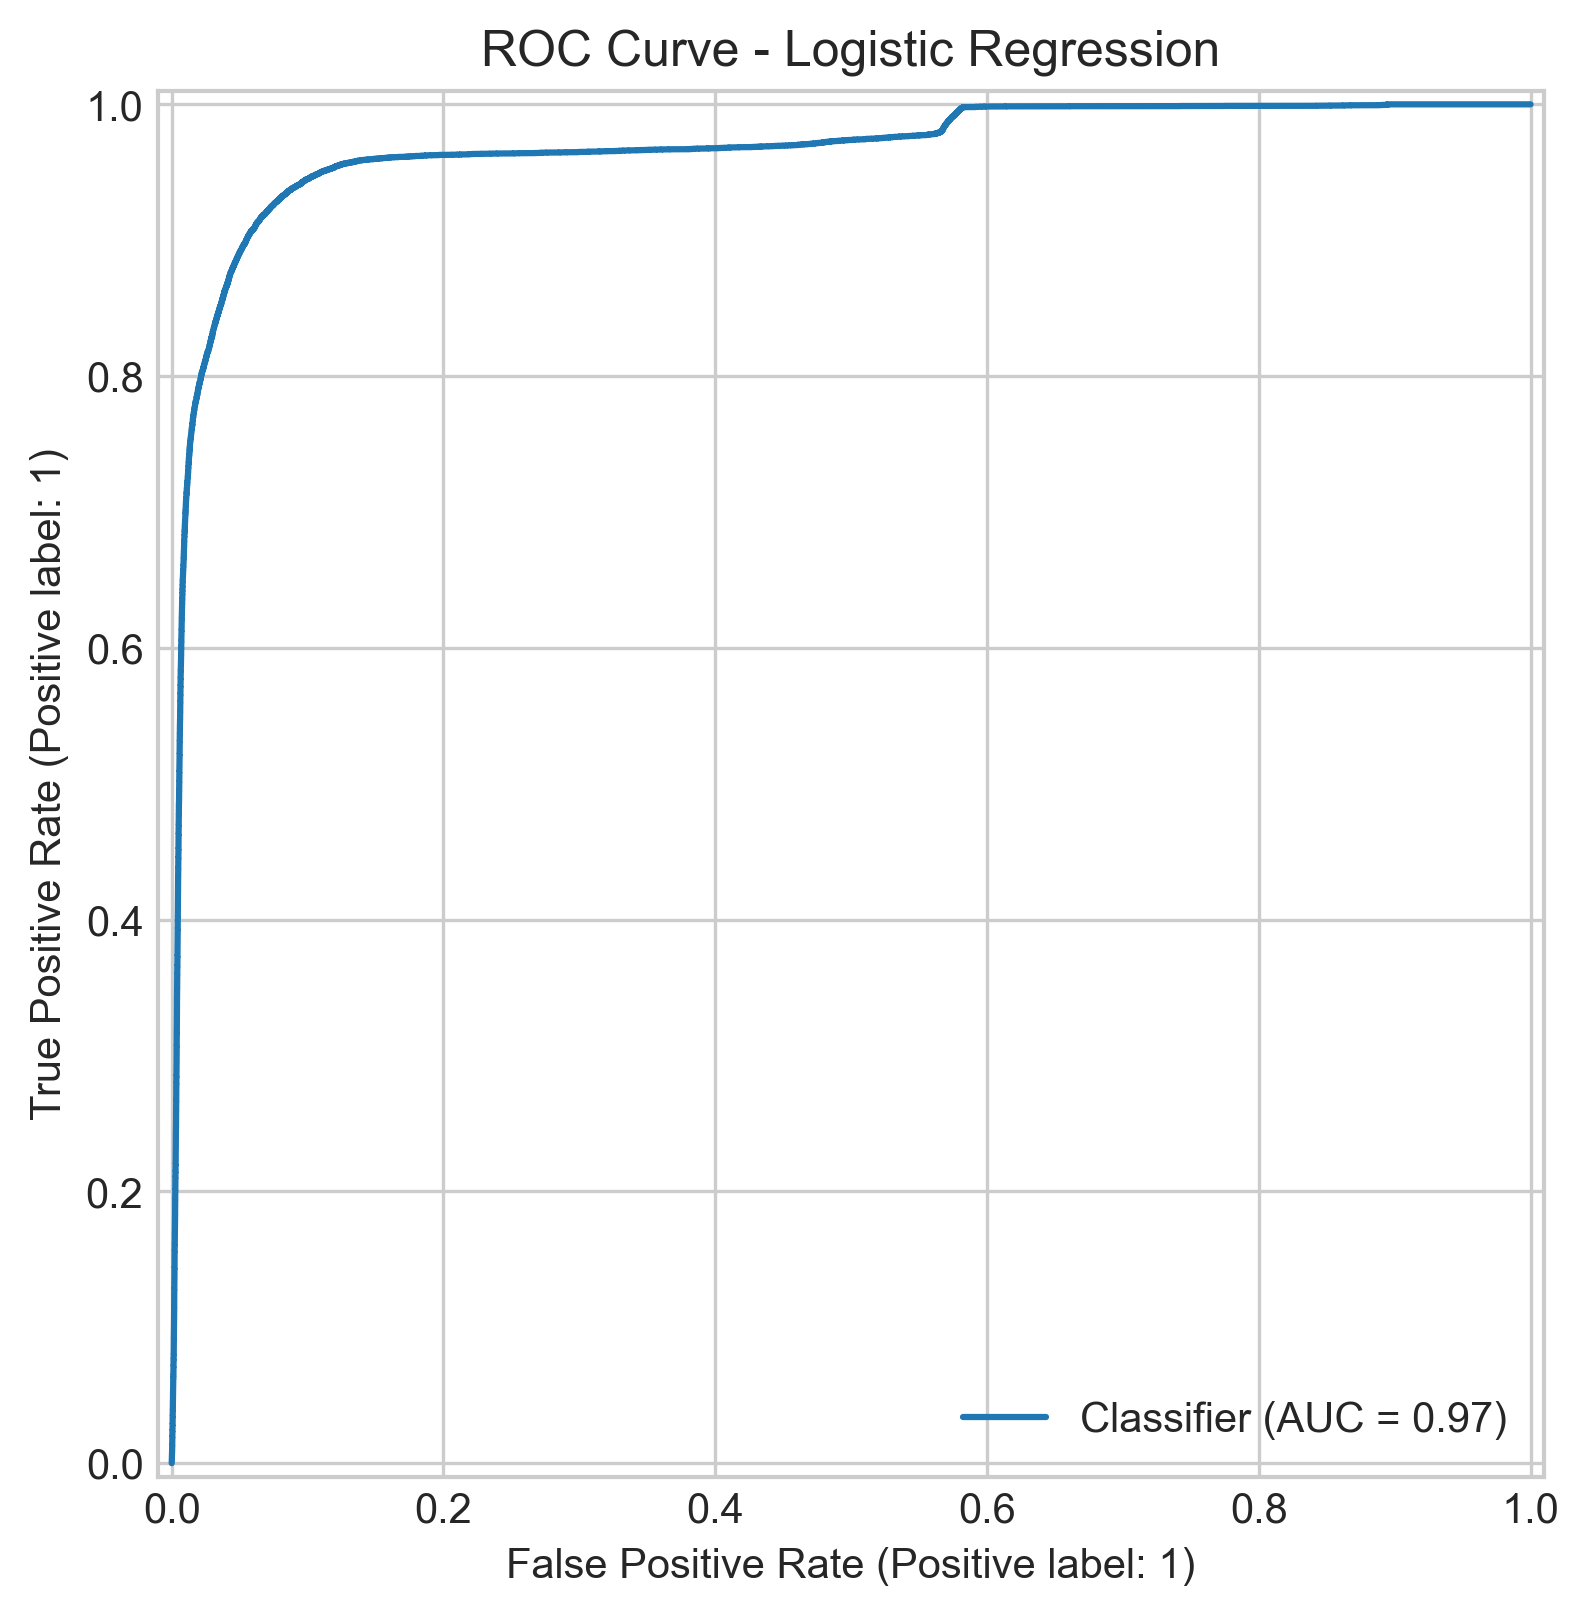

Average Precision: 0.8050561291766394


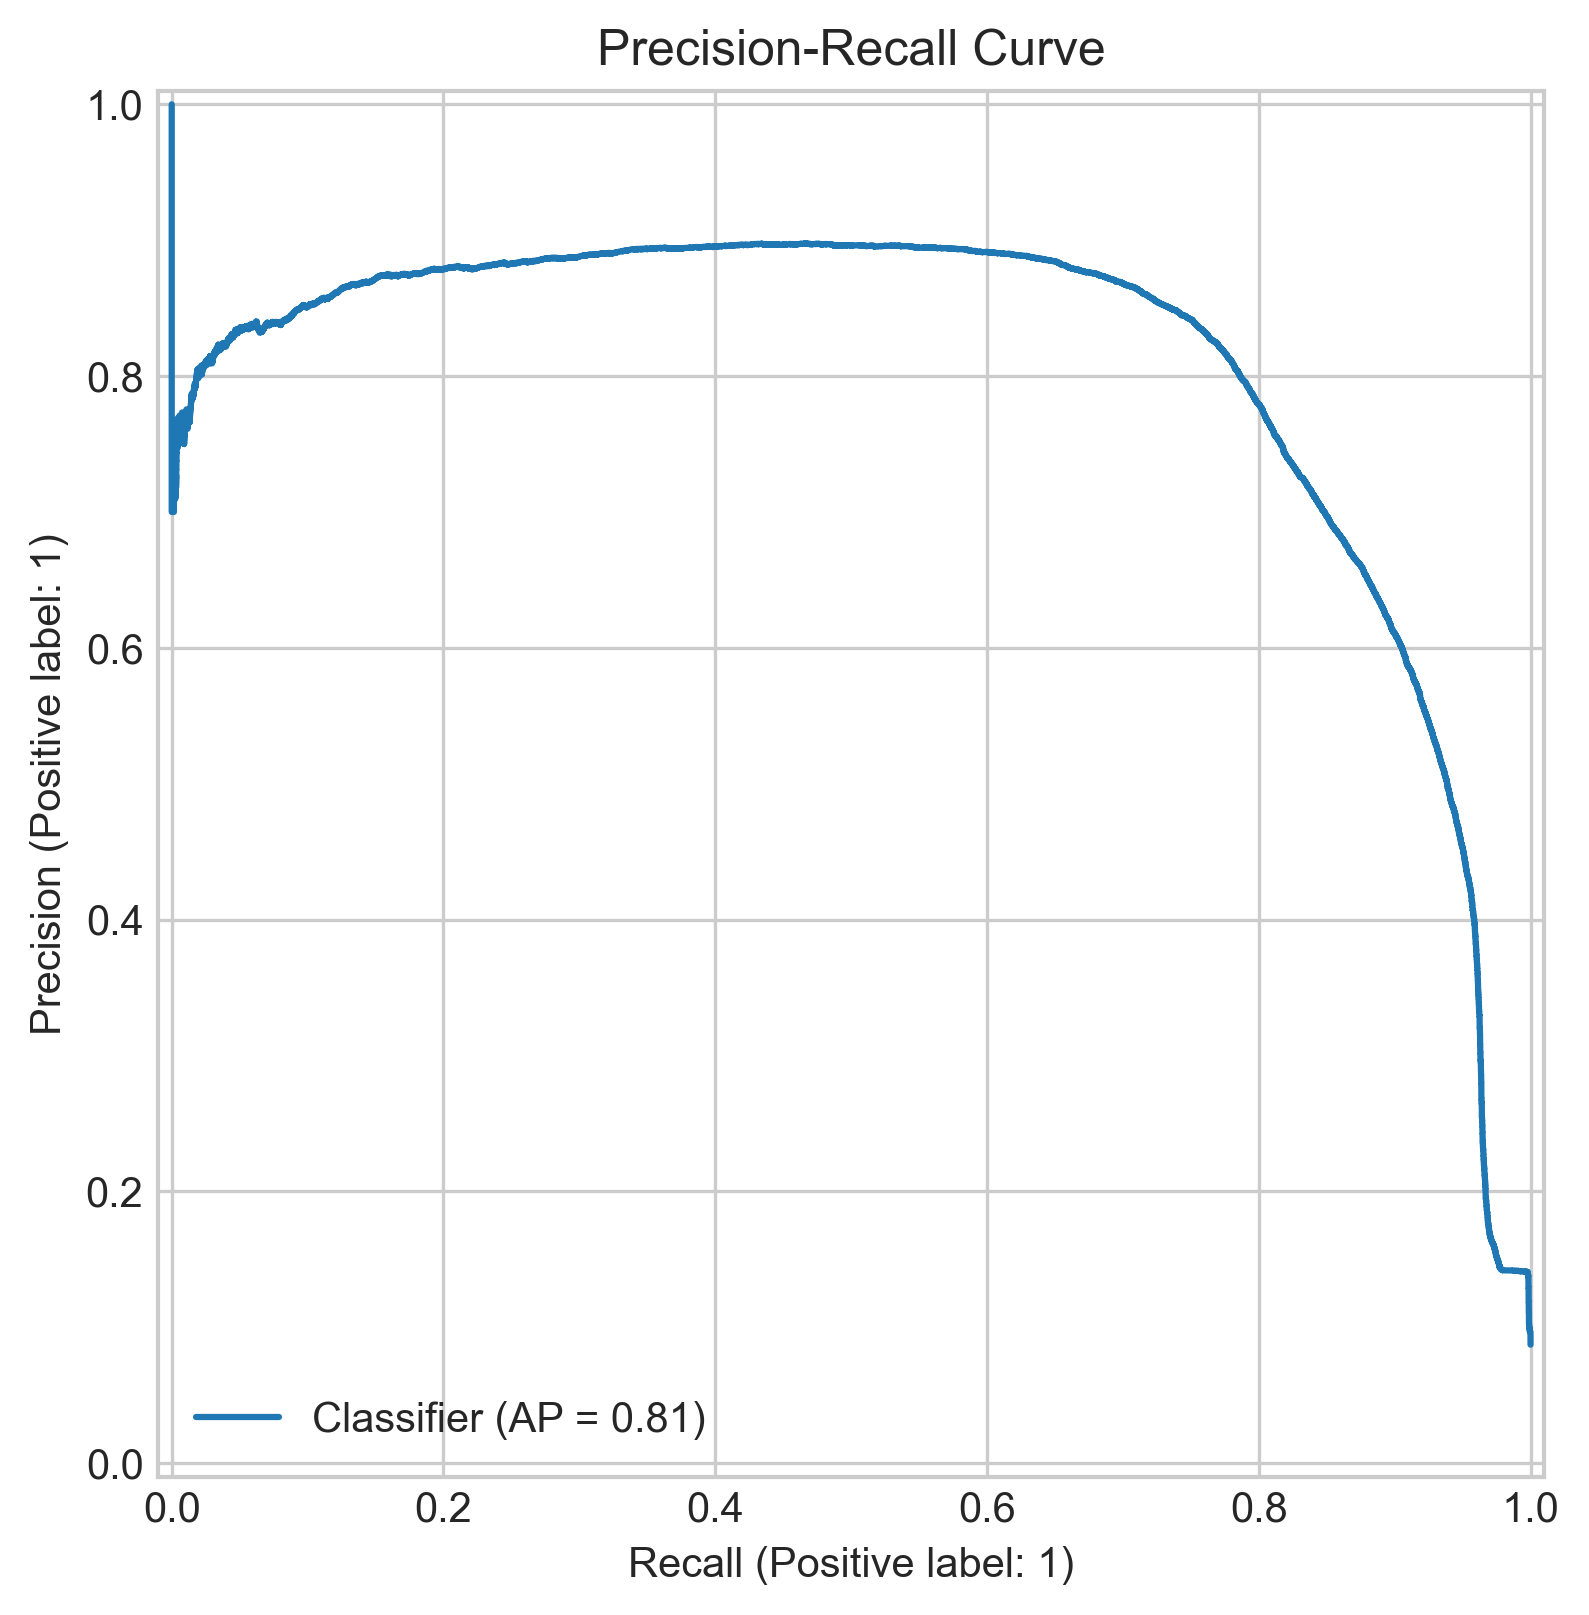

In [84]:
from sklearn.metrics import (
    classification_report,
    average_precision_score,
    PrecisionRecallDisplay
)

print(classification_report(y_test, y_pred_lr))

roc_auc = roc_auc_score(y_test, y_proba_lr)

print("ROC-AUC:", roc_auc)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_lr
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

ap_score = average_precision_score(
    y_test,
    y_proba_lr
)

print("Average Precision:", ap_score)

# PR Curve
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_lr
)

plt.title("Precision-Recall Curve")
plt.show()

In [85]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 0.91, 0.1)

rows = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_lr >= threshold).astype(int)

    rows.append({
        "threshold": threshold,
        "precision_fraud": precision_score(y_test, y_pred_threshold),
        "recall_fraud": recall_score(y_test, y_pred_threshold),
        "f1_fraud": f1_score(y_test, y_pred_threshold),
        "predicted_fraud_count": y_pred_threshold.sum()
    })

threshold_results = pd.DataFrame(rows)

threshold_results

,threshold,precision_fraud,recall_fraud,f1_fraud,predicted_fraud_count
0,0.1,0.497464,0.939001,0.650373,32925
1,0.2,0.689260,0.854669,0.763104,21629
2,0.3,0.810980,0.779969,0.795172,16776
3,0.4,0.871645,0.690650,0.770663,13821
4,0.5,0.891491,0.600069,0.717311,11741
5,0.6,0.895429,0.518890,0.657036,10108
6,0.7,0.896788,0.441839,0.592004,8594
7,0.8,0.893802,0.366221,0.519561,7147
8,0.9,0.886905,0.281890,0.427807,5544


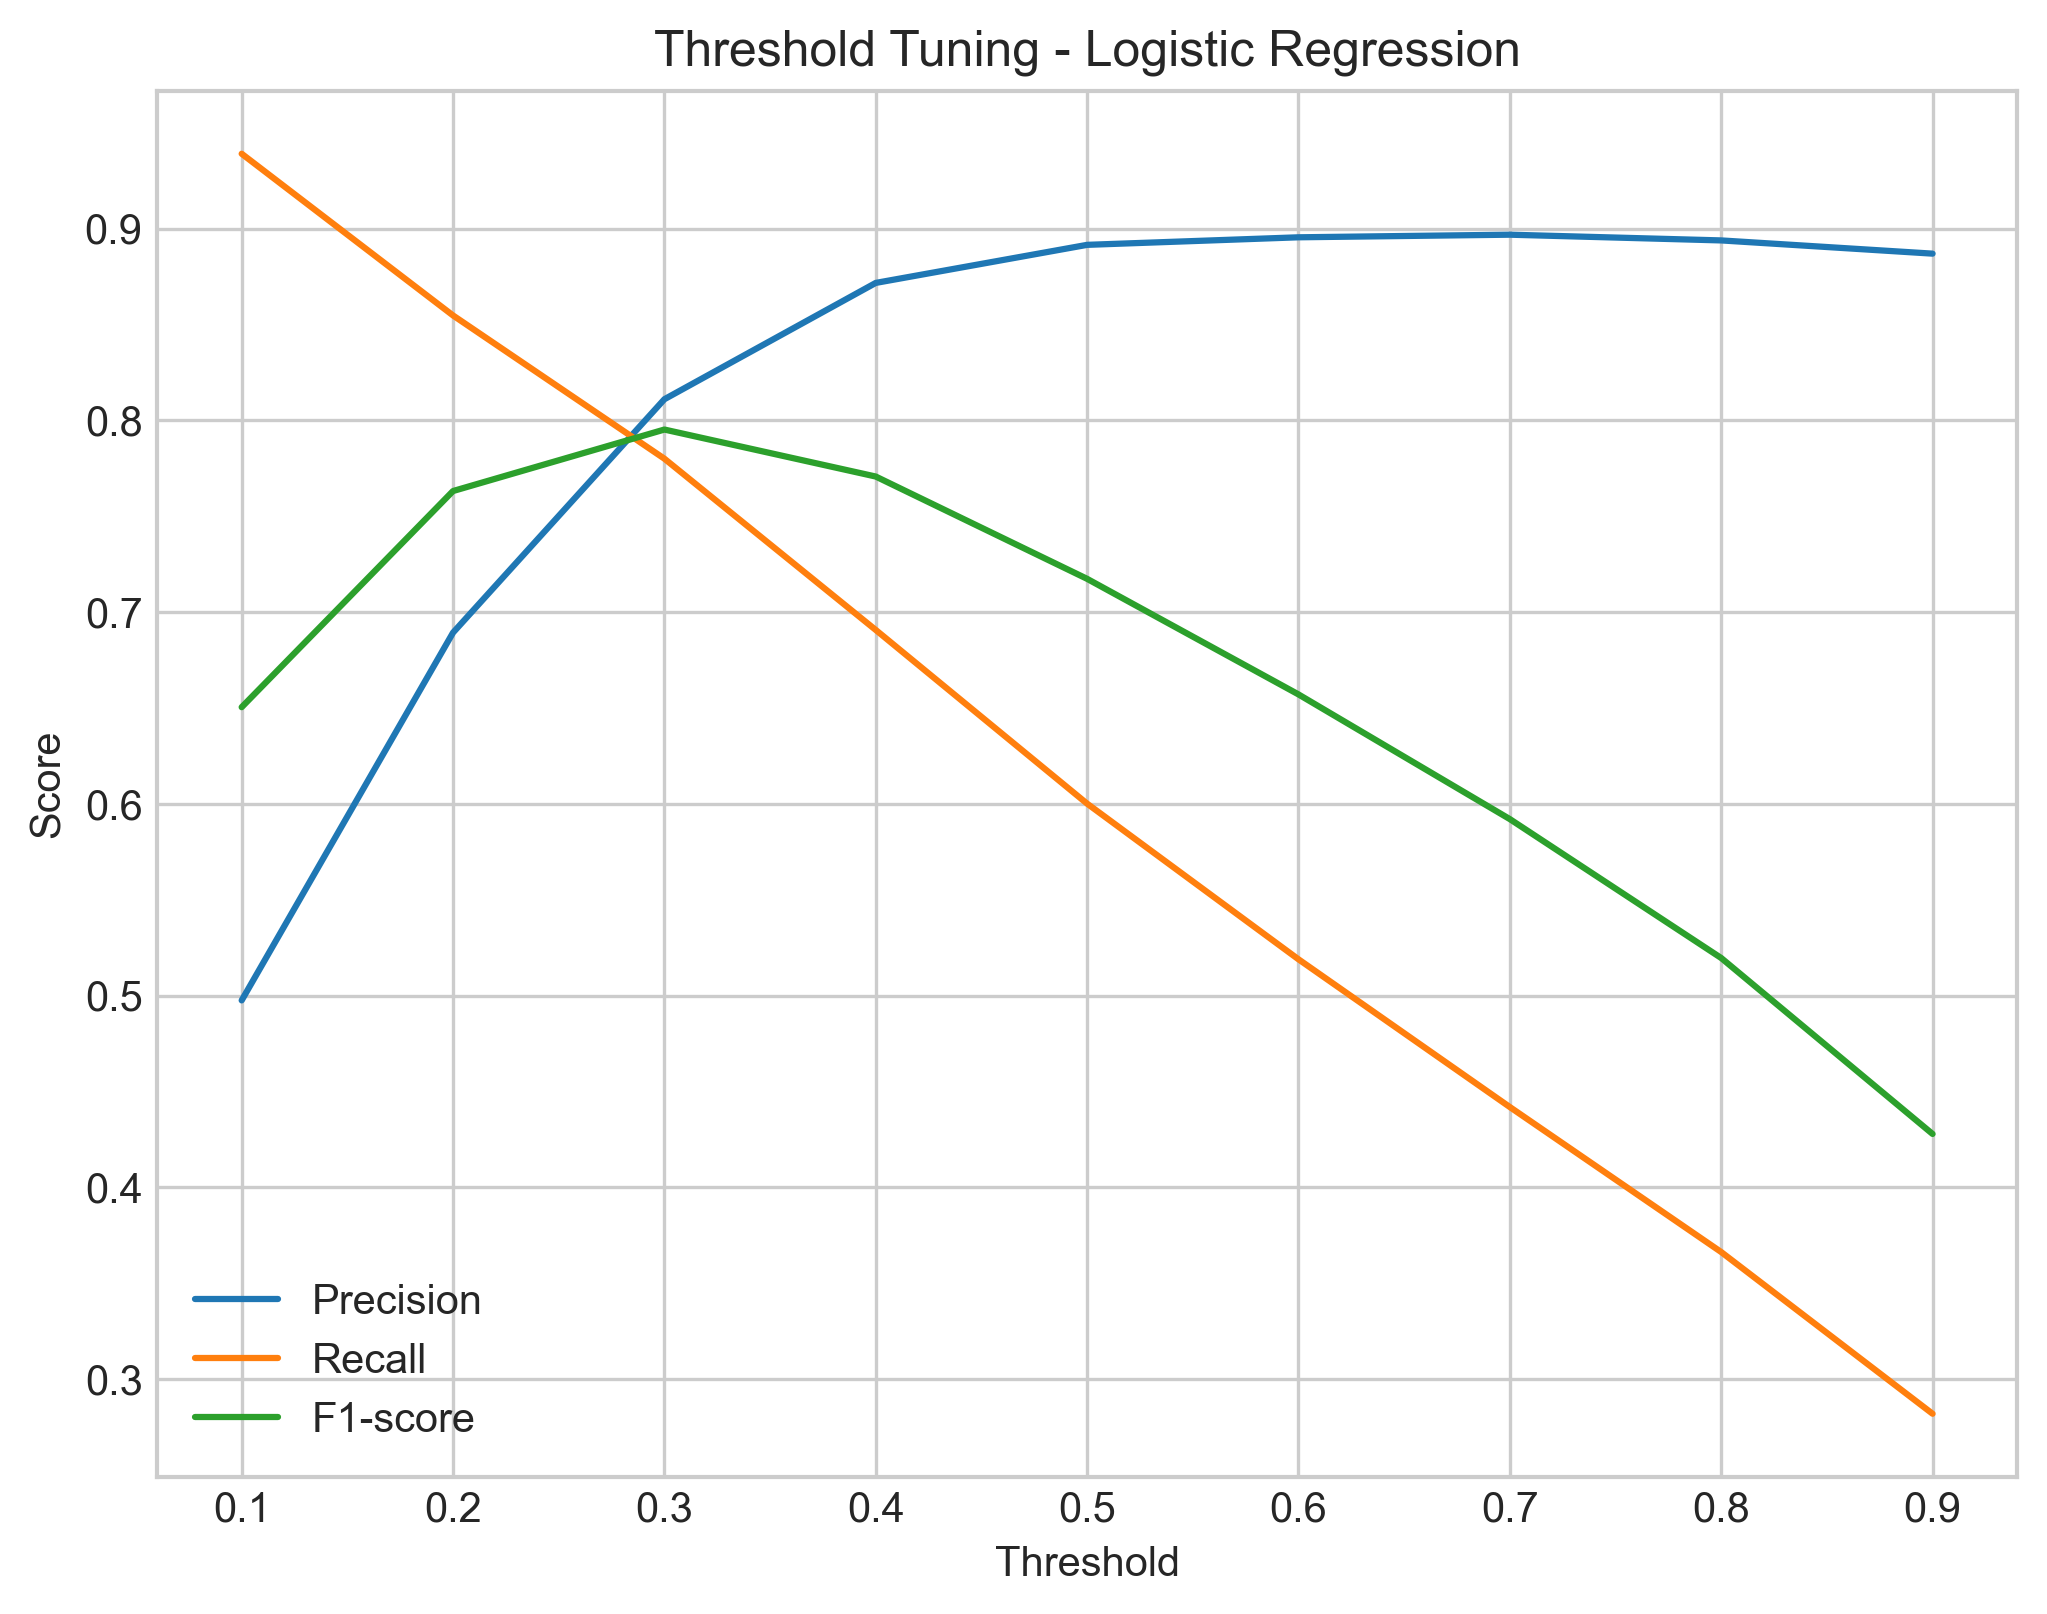

In [86]:
plt.plot(threshold_results["threshold"], threshold_results["precision_fraud"], label="Precision")
plt.plot(threshold_results["threshold"], threshold_results["recall_fraud"], label="Recall")
plt.plot(threshold_results["threshold"], threshold_results["f1_fraud"], label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

### Random Forest

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    182557
         1.0       1.00      1.00      1.00     17443

    accuracy                           1.00    200000
   macro avg       1.00      1.00      1.00    200000
weighted avg       1.00      1.00      1.00    200000

ROC-AUC: 0.9999999987438534
Average Precision: 0.9999999868544038


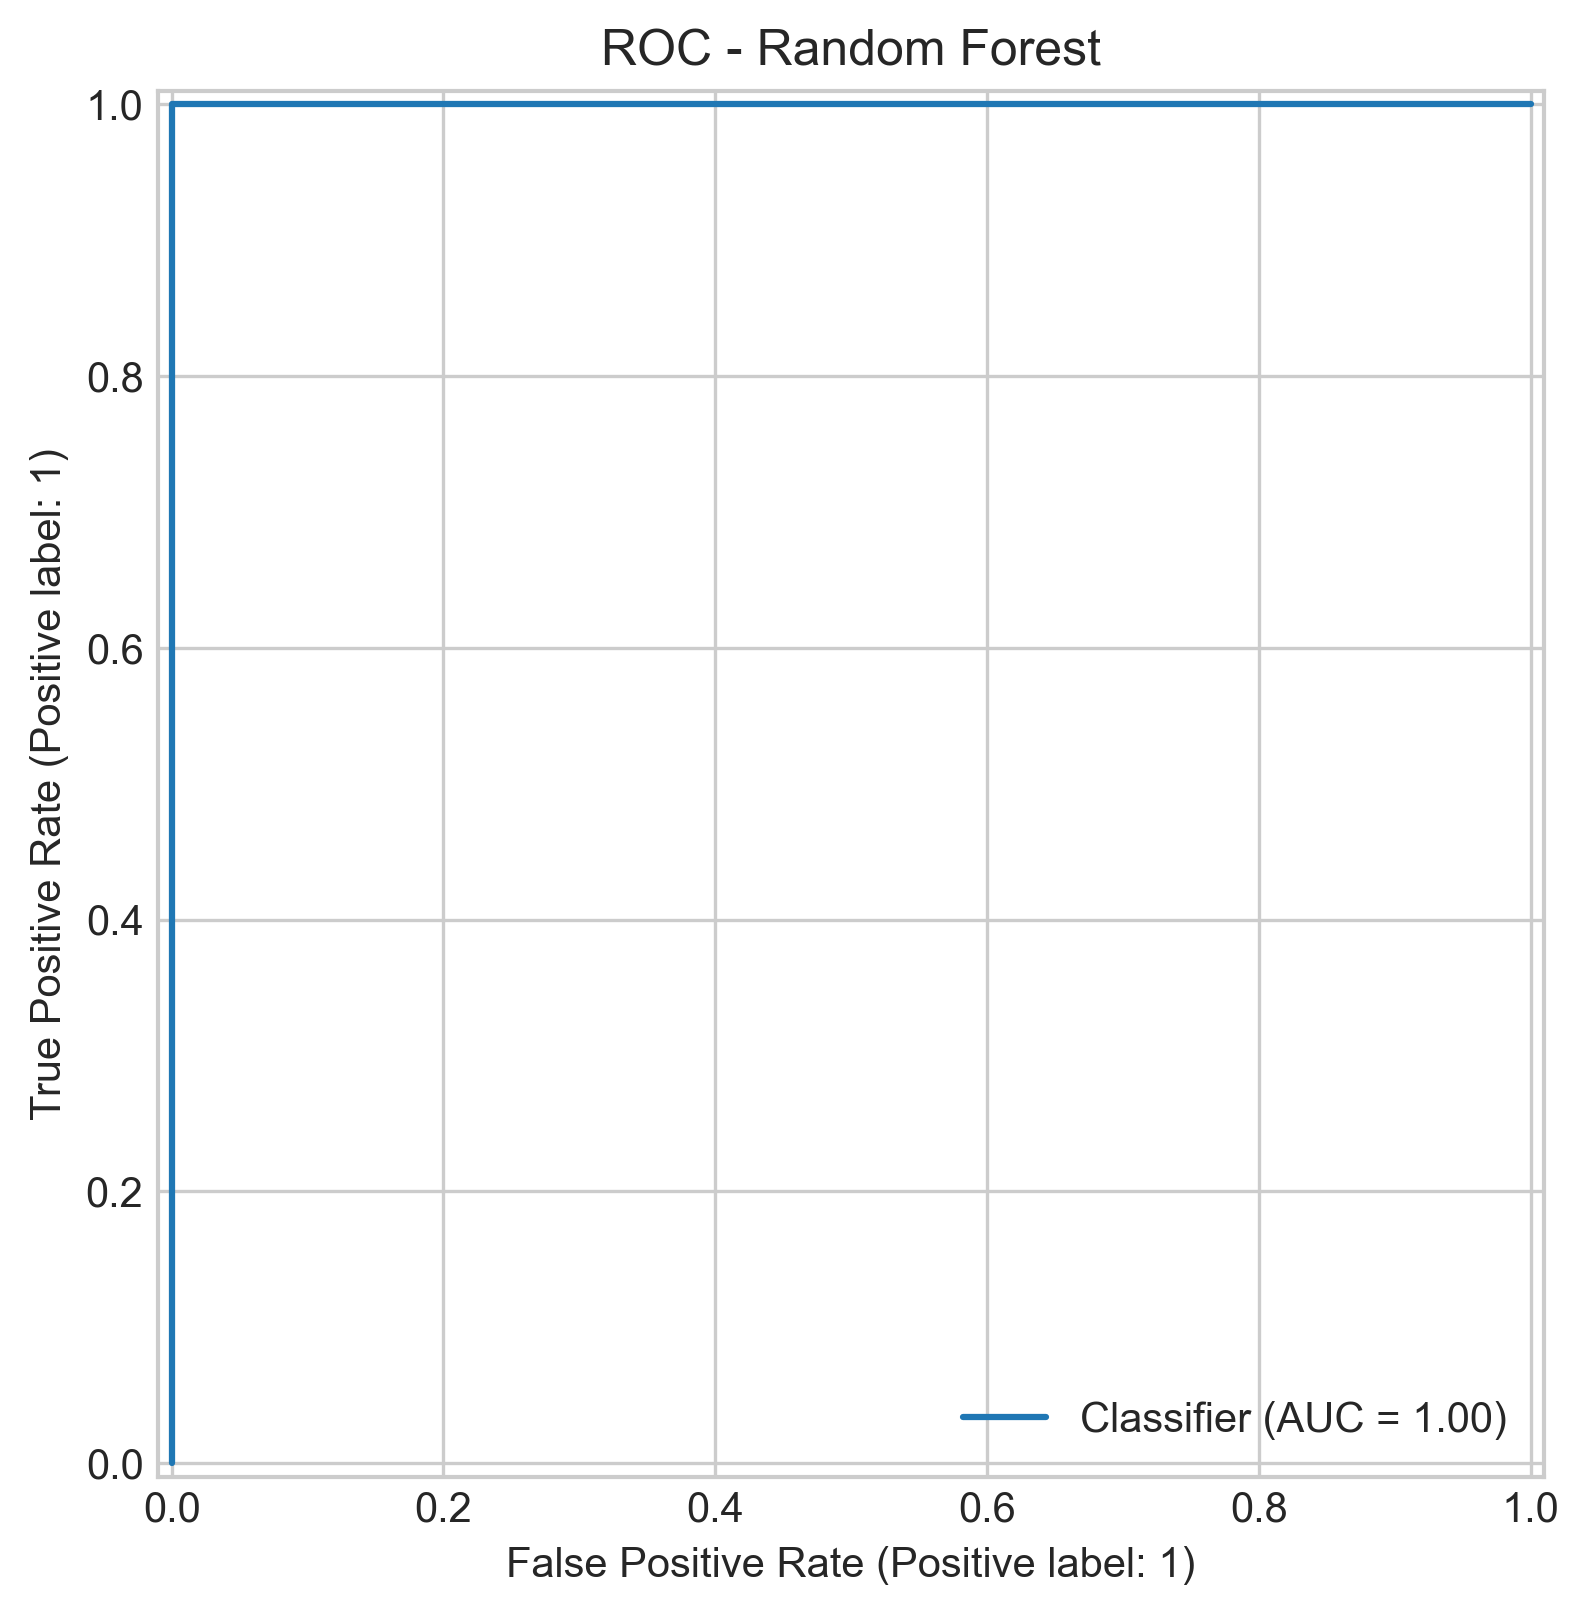

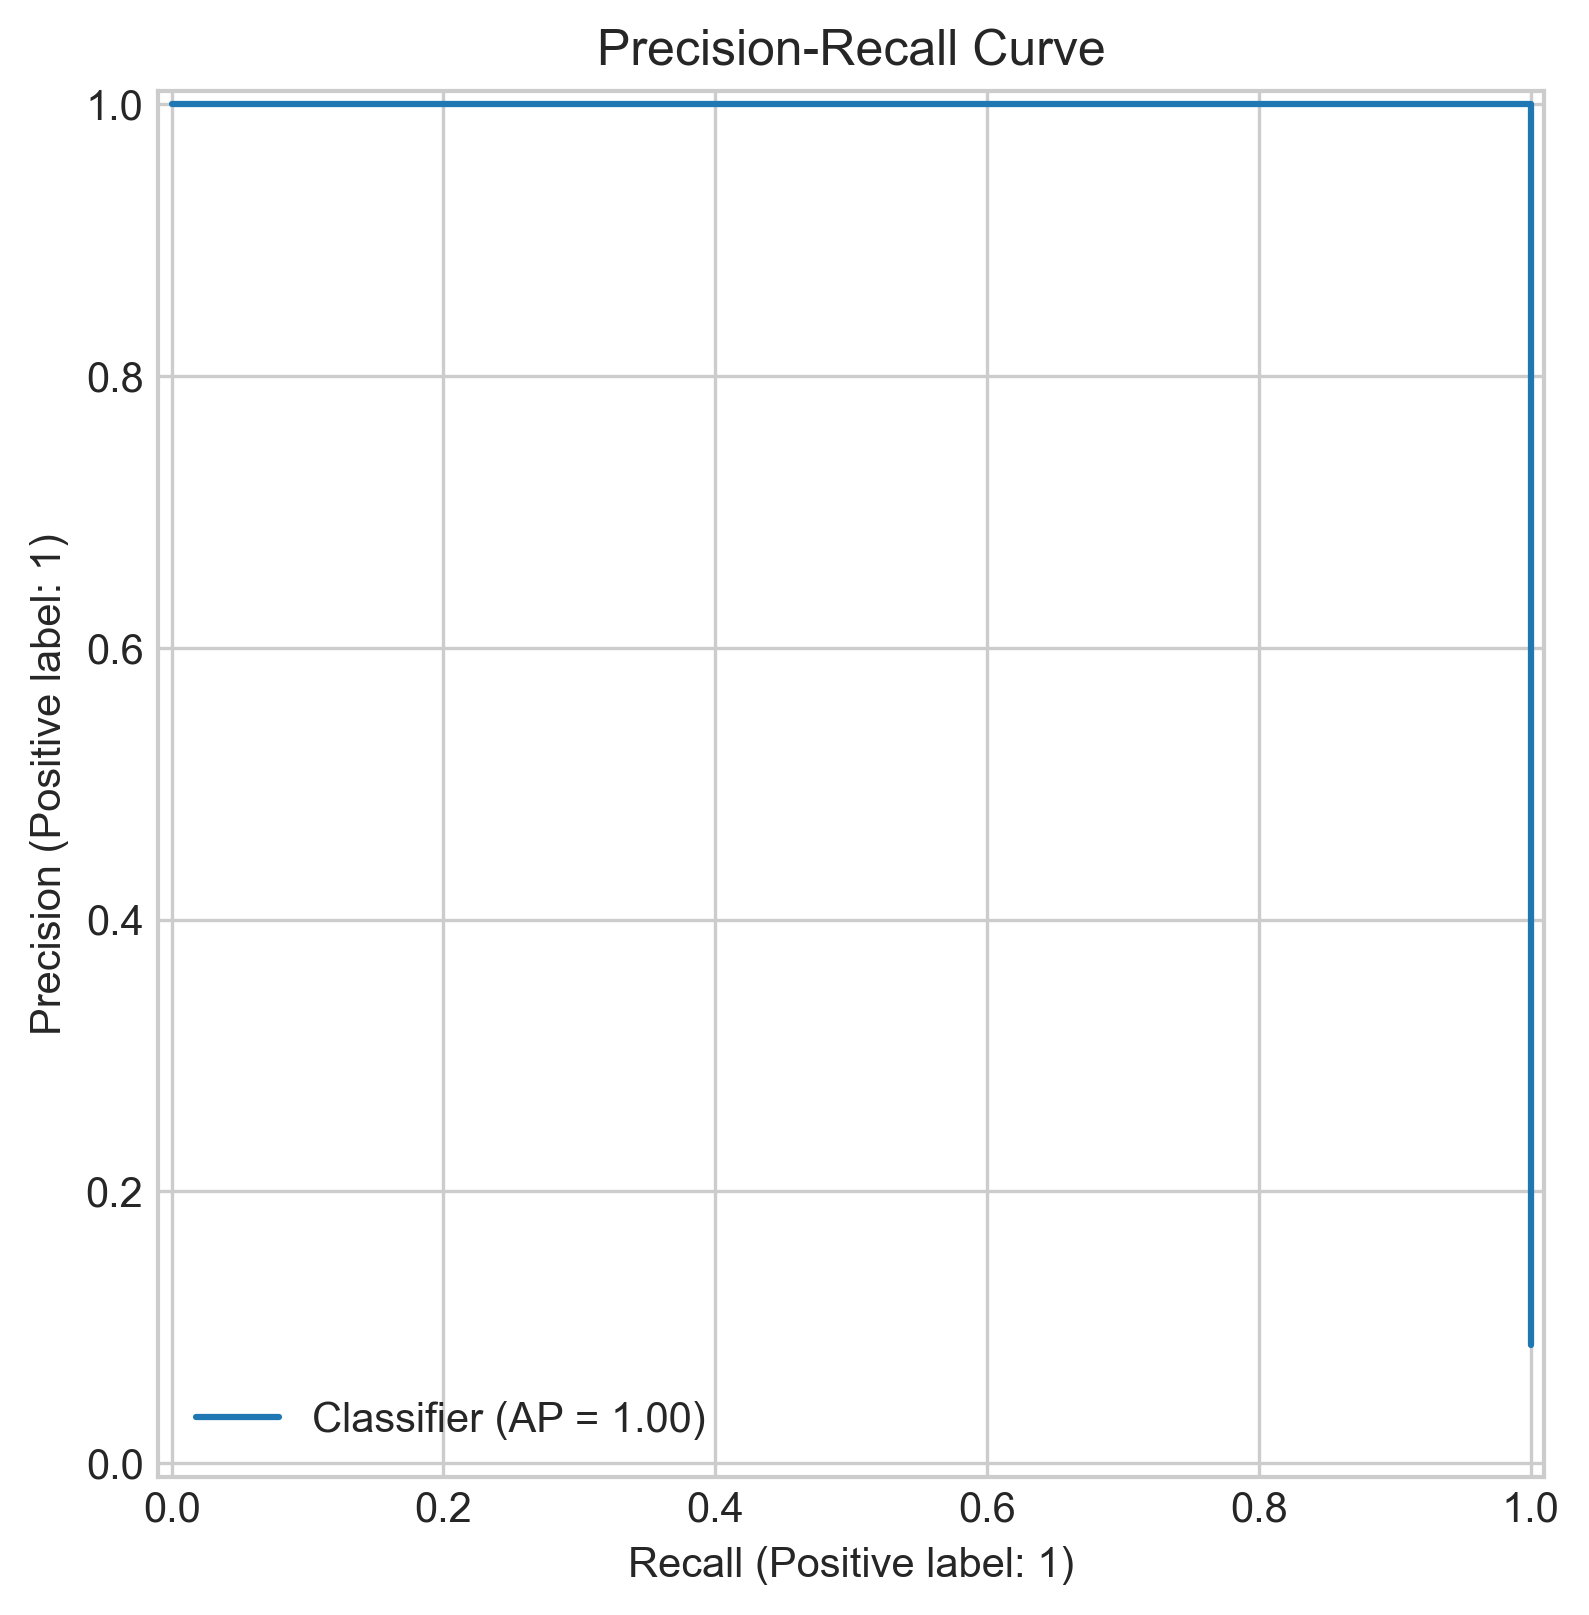

In [88]:
roc_auc = roc_auc_score(y_test, y_proba_rf)
ap_score = average_precision_score(y_test, y_proba_rf)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc)
print("Average Precision:", ap_score)

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC - Random Forest")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Precision-Recall Curve")
plt.show()

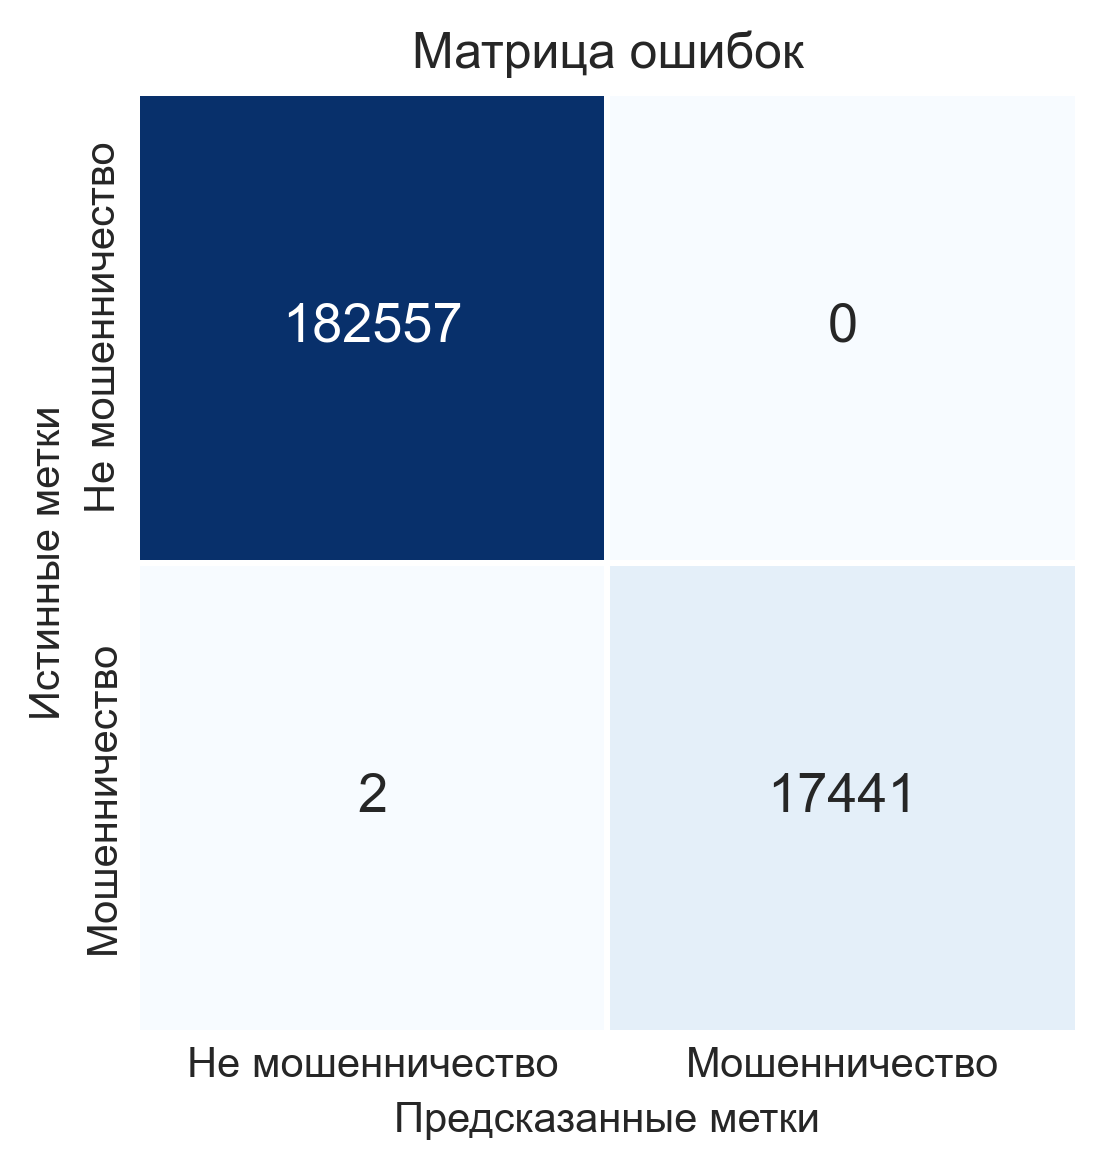

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4, 4), dpi=300)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=1,
    linecolor="white",
    xticklabels=["Не мошенничество", "Мошенничество"],
    yticklabels=["Не мошенничество", "Мошенничество"],
    annot_kws={"size": 13}
)

plt.xlabel("Предсказанные метки")
plt.ylabel("Истинные метки")
plt.title("Матрица ошибок")
plt.tight_layout()
plt.show()

### XGBoost

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
roc_auc = roc_auc_score(y_test, y_proba_rf)
ap_score = average_precision_score(y_test, y_proba_rf)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc)
print("Average Precision:", ap_score)

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC - Random Forest")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4, 4), dpi=300)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    square=True,
    linewidths=1,
    linecolor="white",
    xticklabels=["Не мошенничество", "Мошенничество"],
    yticklabels=["Не мошенничество", "Мошенничество"],
    annot_kws={"size": 13}
)

plt.xlabel("Предсказанные метки")
plt.ylabel("Истинные метки")
plt.title("Матрица ошибок")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="importance",
    ascending=False
)